# Portfolio Risk Posture: Q4 2023

Aggregate risk metrics across 800 CVEs for executive review. Measures exposure, remediation velocity, and coordination quality.

Unlike the tactical triage in notebook 08, this report shows **portfolio-level** statistics -- no individual CVE tables, only aggregate metrics and visualizations suitable for CISO / board consumption.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vulnstate import CVDArray, CVDEvent

`import_nvd` accepts a file path directly and uses `orjson` internally for fast parsing. EPSS and KEV enrichment layers add exploitation probability and federal mandate data respectively.

In [ ]:
arr = CVDArray()
arr.import_nvd("sample_nvdcve_2023.json")
arr.import_epss("sample_epss.csv")
arr.import_kev("sample_kev.csv")
arr.import_csv("sample_deployed.csv", cve_column="cve_id", event=CVDEvent.D, timestamp_column="deployed_date")
result = arr.analysis

# Derive severity tiers from CVSS base scores
cvss = arr.cvss_scores
severity = np.where(cvss >= 9.0, "CRITICAL",
           np.where(cvss >= 7.0, "HIGH",
           np.where(cvss >= 4.0, "MEDIUM",
           np.where(cvss >= 0.1, "LOW", "NONE"))))

# Key performance indicators
total = len(arr)
critical_count = int((severity == "CRITICAL").sum())
patch_rate = arr.has_event_occurred(CVDEvent.F).sum() / total * 100
kev_total = int(arr.kev.sum())
kev_fixed = int((arr.kev & arr.has_event_occurred(CVDEvent.F)).sum())
kev_compliance = kev_fixed / kev_total * 100 if kev_total > 0 else 100.0
mean_coord = float(result.desiderata_score.mean())

print(f"Portfolio: {total} CVEs | Critical: {critical_count} | "
      f"Patch rate: {patch_rate:.0f}% | KEV compliance: {kev_compliance:.0f}% | "
      f"Coordination: {mean_coord:.2f}")

## Exposure Summary

Four-panel overview: severity breakdown, fix path progression stage, active threat indicators, and key risk numbers. The fix path tracks V(endor aware) -> F(ix ready) -> D(eployed), while threat indicators show how many CVEs have public exploits or observed attacks.

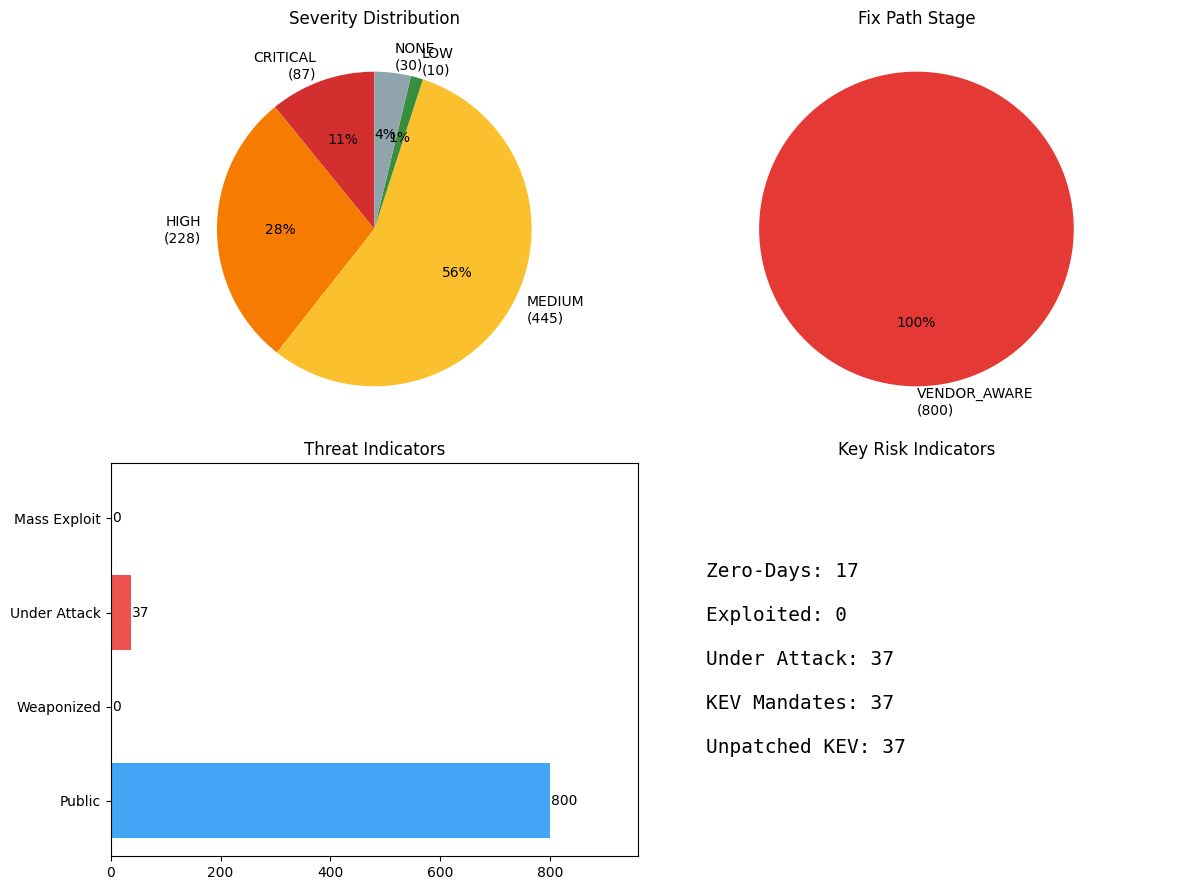

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Top-left: Severity distribution pie
sev_order = ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE"]
sev_counts = [int((severity == s).sum()) for s in sev_order]
sev_colors = ["#d32f2f", "#f57c00", "#fbc02d", "#388e3c", "#90a4ae"]
nonzero = [(s, c, col) for s, c, col in zip(sev_order, sev_counts, sev_colors) if c > 0]
axes[0, 0].pie([x[1] for x in nonzero], labels=[f"{x[0]}\n({x[1]})" for x in nonzero],
              colors=[x[2] for x in nonzero], autopct="%1.0f%%", startangle=90)
axes[0, 0].set_title("Severity Distribution")

# Top-right: Fix path distribution pie
fix_path_counts = arr.count_by_fix_path()
fp_labels = [fp.name for fp in fix_path_counts.keys()]
fp_values = list(fix_path_counts.values())
fp_colors = ["#e53935", "#fb8c00", "#43a047", "#1565c0"]
nonzero_fp = [(l, v, c) for l, v, c in zip(fp_labels, fp_values, fp_colors) if v > 0]
axes[0, 1].pie([x[1] for x in nonzero_fp], labels=[f"{x[0]}\n({x[1]})" for x in nonzero_fp],
              colors=[x[2] for x in nonzero_fp], autopct="%1.0f%%", startangle=90)
axes[0, 1].set_title("Fix Path Stage")

# Bottom-left: Threat state bar
threat_labels = ["Public", "Weaponized", "Under Attack", "Mass Exploit"]
threat_counts = [
    int(arr.has_event_occurred(CVDEvent.P).sum()),
    int(arr.has_event_occurred(CVDEvent.X).sum()),
    int(arr.has_event_occurred(CVDEvent.A).sum()),
    int(result.is_mass_exploitation.sum()),
]
bars = axes[1, 0].barh(threat_labels, threat_counts, color=["#42a5f5", "#ff7043", "#ef5350", "#b71c1c"])
for bar, count in zip(bars, threat_counts):
    axes[1, 0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                    str(count), va="center", fontsize=10)
axes[1, 0].set_title("Threat Indicators")
axes[1, 0].set_xlim(0, max(threat_counts) * 1.2)

# Bottom-right: KPI text panel
axes[1, 1].axis("off")
zero_day_count = int(result.is_zero_day.sum())
exploited_count = int(arr.has_event_occurred(CVDEvent.X).sum())
attack_count = int(arr.has_event_occurred(CVDEvent.A).sum())
kpi_text = (
    f"Zero-Days: {zero_day_count}\n\n"
    f"Exploited: {exploited_count}\n\n"
    f"Under Attack: {attack_count}\n\n"
    f"KEV Mandates: {kev_total}\n\n"
    f"Unpatched KEV: {kev_total - kev_fixed}"
)
axes[1, 1].text(0.1, 0.5, kpi_text, transform=axes[1, 1].transAxes,
               fontsize=14, verticalalignment="center", fontfamily="monospace")
axes[1, 1].set_title("Key Risk Indicators")

plt.tight_layout()
plt.show()

## Remediation Velocity

Fix lag measures days from Vendor Awareness (V) to Fix Ready (F). The histogram shows the distribution, SLA lines mark common remediation targets, and the CDF overlay shows cumulative compliance at each threshold.

In [ ]:
fix_lag = result.fix_lag_days
valid_fix = fix_lag[~np.isnan(fix_lag) & (fix_lag >= 0)]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(valid_fix, bins=40, color="#42a5f5", edgecolor="white", alpha=0.8, label="Fix lag (days)")

# SLA reference lines
for days, color, label in [(30, "green", "30-day SLA"), (60, "orange", "60-day SLA"), (90, "red", "90-day SLA")]:
    ax.axvline(days, color=color, linestyle="--", linewidth=1.5, label=label)

# Compliance percentages
pct_30 = (valid_fix <= 30).sum() / len(valid_fix) * 100 if len(valid_fix) > 0 else 0
pct_60 = (valid_fix <= 60).sum() / len(valid_fix) * 100 if len(valid_fix) > 0 else 0
pct_90 = (valid_fix <= 90).sum() / len(valid_fix) * 100 if len(valid_fix) > 0 else 0
ax.text(0.98, 0.95, f"{pct_30:.0f}% within 30d\n{pct_60:.0f}% within 60d\n{pct_90:.0f}% within 90d",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# CDF overlay on secondary axis
ax2 = ax.twinx()
sorted_fix = np.sort(valid_fix)
cdf = np.arange(1, len(sorted_fix) + 1) / len(sorted_fix) * 100
ax2.plot(sorted_fix, cdf, color="#1a237e", linewidth=2, label="Cumulative %")
ax2.set_ylabel("Cumulative %", color="#1a237e")
ax2.set_ylim(0, 105)

ax.set_xlabel("Days from Vendor Awareness to Fix")
ax.set_ylabel("Count")
ax.set_title("Remediation Velocity: Time to Fix")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

## Exploitation Risk

EPSS (Exploit Prediction Scoring System) provides a probability of exploitation in the next 30 days, independent of CVSS severity. Comparing mean EPSS and actual attack rates across severity tiers reveals whether higher-severity vulnerabilities are actually exploited more frequently.

In [ ]:
df = arr.to_dataframe(include_events=True)
df["severity"] = severity

sev_tiers = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
epss_means = []
attack_rates = []

for tier in sev_tiers:
    mask = df["severity"] == tier
    subset = df[mask]
    epss_means.append(subset["epss"].mean() if len(subset) > 0 else 0)
    attack_rates.append(subset["is_under_attack"].mean() * 100 if len(subset) > 0 else 0)

x = np.arange(len(sev_tiers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, epss_means, width, label="Mean EPSS", color="#ef5350")
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, attack_rates, width, label="Attack Rate %", color="#42a5f5", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(sev_tiers)
ax.set_ylabel("Mean EPSS Score")
ax2.set_ylabel("Attack Rate (%)")
ax.set_title("Exploitation Risk by Severity Tier")

if epss_means[0] > 0 and epss_means[2] > 0:
    ratio = epss_means[0] / epss_means[2]
    ax.text(0.02, 0.95, f"CRITICAL vulns have {ratio:.1f}x exploitation probability vs MEDIUM",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

## KEV Mandate Compliance

The CISA Known Exploited Vulnerabilities catalog represents **mandatory** remediation obligations for federal agencies. Unpatched KEV entries are compliance failures with enforceable deadlines.

In [ ]:
kev_mask = arr.kev
kev_fixed_mask = kev_mask & arr.has_event_occurred(CVDEvent.F)
kev_unfixed_mask = kev_mask & ~arr.has_event_occurred(CVDEvent.F)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Compliance bar
axes[0].bar(["Fixed", "Unpatched"], [kev_fixed, kev_total - kev_fixed],
           color=["#43a047", "#e53935"])
axes[0].set_title(f"KEV Fix Status (n={kev_total})")
axes[0].set_ylabel("Count")
for i, v in enumerate([kev_fixed, kev_total - kev_fixed]):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# KEV by severity
kev_severity = severity[kev_mask]
kev_sev_counts = [int((kev_severity == s).sum()) for s in sev_order if (kev_severity == s).sum() > 0]
kev_sev_labels = [s for s in sev_order if (kev_severity == s).sum() > 0]
kev_sev_colors = [c for s, c in zip(sev_order, sev_colors) if (kev_severity == s).sum() > 0]
axes[1].barh(kev_sev_labels, kev_sev_counts, color=kev_sev_colors)
axes[1].set_title("KEV by Severity")
axes[1].set_xlabel("Count")

# Unfixed KEV age
kev_disc_window = result.disclosure_window_days[kev_unfixed_mask]
valid_age = kev_disc_window[~np.isnan(kev_disc_window)]
if len(valid_age) > 0:
    axes[2].hist(valid_age, bins=15, color="#e53935", edgecolor="white")
    axes[2].axvline(np.median(valid_age), color="black", linestyle="--", label=f"Median: {np.median(valid_age):.0f}d")
    axes[2].legend()
axes[2].set_title("Unfixed KEV: Days Since Disclosure")
axes[2].set_xlabel("Days")

plt.tight_layout()
plt.show()

## Coordination Scorecard

The desiderata score (0-1) measures how many of the 12 ideal event orderings were satisfied. A score of 1.0 means all events happened in the preferred order (V before P before X, fix before exploit, etc). The breakdown shows what fraction of the portfolio achieved coordinated, responsible, or premature disclosure.

In [ ]:
scores = result.desiderata_score
valid_scores = scores[~np.isnan(scores)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score gauge
mean_score = float(valid_scores.mean()) if len(valid_scores) > 0 else 0
axes[0].barh(["Portfolio"], [mean_score], color="#1565c0", height=0.4)
axes[0].barh(["Ideal"], [1.0], color="#c8e6c9", height=0.4)
axes[0].set_xlim(0, 1.1)
axes[0].set_title(f"Mean Coordination Score: {mean_score:.2f} / 1.0")
axes[0].axvline(1.0, color="green", linestyle="-", alpha=0.3)

# Disclosure quality breakdown
coordinated_pct = result.is_coordinated.sum() / total * 100
premature_pct = result.is_premature_disclosure.sum() / total * 100
responsible_pct = result.is_responsible_disclosure.sum() / total * 100

labels = ["Coordinated\n(V before P)", "Premature\n(P before F)", "Responsible\n(V->P->F)"]
values = [coordinated_pct, premature_pct, responsible_pct]
colors = ["#43a047", "#e53935", "#1565c0"]
bars = axes[1].bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.0f}%", ha="center", fontweight="bold")
axes[1].set_ylabel("% of Portfolio")
axes[1].set_title("Disclosure Quality Breakdown")
axes[1].set_ylim(0, max(values) * 1.2 if max(values) > 0 else 100)

plt.tight_layout()
plt.show()

## Attack Surface Breakdown

CVSS attack vector (parsed from the vector string) indicates how the vulnerability can be reached. Network-accessible vulnerabilities typically carry higher exploitation probability since they're reachable without physical or adjacent access.

In [ ]:
av = arr.attack_vector
av_labels_map = {"N": "Network", "A": "Adjacent", "L": "Local", "P": "Physical"}

av_stats = []
for code, label in av_labels_map.items():
    mask = av == code
    count = int(mask.sum())
    if count == 0:
        continue
    mean_epss = float(np.nanmean(arr.epss[mask]))
    kev_rate = float(arr.kev[mask].sum() / count * 100)
    av_stats.append({"vector": label, "count": count, "mean_epss": mean_epss, "kev_rate": kev_rate})

av_df = pd.DataFrame(av_stats)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(av_df))
width = 0.3

ax.bar(x - width, av_df["count"], width, label="Count", color="#42a5f5")
ax2 = ax.twinx()
ax2.bar(x, av_df["mean_epss"], width, label="Mean EPSS", color="#ef5350", alpha=0.8)
ax2.bar(x + width, av_df["kev_rate"] / 100, width, label="KEV Rate", color="#66bb6a", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(av_df["vector"])
ax.set_ylabel("Count")
ax2.set_ylabel("Rate (0-1)")
ax.set_title("Attack Surface: Distribution and Risk by Vector")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

av_df.set_index("vector")

## Risk Trend Indicators

Summary scorecard with conditional status. Thresholds: patch rate >=80% OK, KEV compliance >=90% OK, zero-days <=5 OK, fix lag <=30d OK, coordination >=0.75 OK.

In [ ]:
valid_fix_lag = fix_lag[~np.isnan(fix_lag) & (fix_lag >= 0)]
mean_fix_lag = float(valid_fix_lag.mean()) if len(valid_fix_lag) > 0 else np.nan

metrics = pd.DataFrame([
    {"Metric": "Patch Rate", "Value": f"{patch_rate:.0f}%",
     "Status": "OK" if patch_rate >= 80 else ("WARN" if patch_rate >= 60 else "ALERT")},
    {"Metric": "KEV Compliance", "Value": f"{kev_compliance:.0f}%",
     "Status": "OK" if kev_compliance >= 90 else ("WARN" if kev_compliance >= 70 else "ALERT")},
    {"Metric": "Zero-Day Count", "Value": str(zero_day_count),
     "Status": "OK" if zero_day_count <= 5 else ("WARN" if zero_day_count <= 20 else "ALERT")},
    {"Metric": "Mean Fix Lag", "Value": f"{mean_fix_lag:.0f} days",
     "Status": "OK" if mean_fix_lag <= 30 else ("WARN" if mean_fix_lag <= 60 else "ALERT")},
    {"Metric": "Coordination Score", "Value": f"{mean_coord:.2f}",
     "Status": "OK" if mean_coord >= 0.75 else ("WARN" if mean_coord >= 0.5 else "ALERT")},
])

def color_status(val):
    colors = {"OK": "background-color: #c8e6c9", "WARN": "background-color: #fff9c4", "ALERT": "background-color: #ffcdd2"}
    return colors.get(val, "")

metrics.style.map(color_status, subset=["Status"])

## Executive Summary

- **Top Risk:** Unpatched KEV vulnerabilities represent mandatory remediation obligations with compliance deadlines
- **Compliance:** KEV fix rate and overall patch rate indicate current posture against mandated timelines
- **Exploitation:** CRITICAL-severity CVEs show disproportionate exploitation probability vs lower tiers
- **Velocity:** Remediation SLA adherence measured against 30/60/90-day benchmarks
- **Coordination:** Portfolio-wide disclosure quality score reflects vendor-researcher coordination effectiveness